In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_csv('train.csv')
df.sample(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
13346,0x18a8,INDORES16DEL03,39,4.9,22.744648,75.894377,22.804648,75.954377,01-03-2022,21:15:00,21:25:00,conditions Stormy,Jam,2,Drinks,electric_scooter,1,No,Metropolitian,(min) 30
27320,0xacef,BANGRES07DEL02,32,4.4,12.978453,77.643685,13.058453,77.723685,18-03-2022,21:10:00,21:25:00,conditions Windy,Jam,1,Drinks,scooter,1,No,Urban,(min) 31
22320,0x45e3,CHENRES01DEL02,32,5,13.005801,80.250744,13.055801,80.300744,15-03-2022,19:20:00,19:25:00,conditions Sandstorms,Jam,2,Buffet,scooter,1,No,Metropolitian,(min) 26
40840,0x8b1e,INDORES17DEL02,29,5,22.761226,75.887522,22.891226,76.017522,18-03-2022,21:20:00,21:30:00,conditions Stormy,Jam,0,Drinks,motorcycle,0,No,Metropolitian,(min) 35
39721,0x5617,BANGRES01DEL01,24,4.9,12.933284,77.615428,13.003284,77.685428,04-03-2022,23:30:00,23:35:00,conditions Windy,Low,1,Meal,scooter,0,No,Urban,(min) 12
37194,0x25ef,MYSRES07DEL01,30,4.4,12.325461,76.632278,12.365461,76.672278,05-03-2022,16:00:00,16:10:00,conditions Windy,Medium,1,Buffet,scooter,1,No,Metropolitian,(min) 31
30565,0x1a18,CHENRES12DEL01,20,4.2,12.972793,80.249982,13.082793,80.359982,27-03-2022,18:50:00,19:05:00,conditions Cloudy,Medium,1,Snack,motorcycle,2,No,Metropolitian,(min) 33
34471,0xc000,DEHRES19DEL01,NaN,NaN,-30.372202,-78.077151,30.482202,78.187151,16-02-2022,NaN,20:05:00,conditions NaN,NaN,3,Snack,scooter,0,No,Metropolitian,(min) 54
1268,0xa378,HYDRES08DEL01,21,5,17.438263,78.397865,17.508263,78.467865,29-03-2022,21:25:00,21:40:00,conditions Sunny,Jam,1,Snack,motorcycle,0,No,Metropolitian,(min) 18
32877,0x69d8,BANGRES11DEL03,27,4.6,12.934365,77.616155,12.994365,77.676155,05-04-2022,20:40:00,20:55:00,conditions Sunny,Jam,1,Drinks,motorcycle,0,No,Urban,(min) 11


In [3]:
df.shape

(45593, 20)

- **Shape of the dataset is 45593 rows and 20 columns**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

**Corrctions**
1. Delivery_person_Age - numerical hona chahiye
2. Delivery_person_Ratings - numerical hona chahiye
3. Date time columns - date time hona chahiye 
4. multiple_deliveries - integer hona chahiye
5. City - iska nam type of city hona chahiye
6. Time_taken(min) - isme (min) hta ke ineger bnana chahiye

- data me NAN hai lekin vo string me NAN likha h
- latitude laungitude 0 aare hai jo misinformation i guess
- 

In [ ]:
df['Weatherconditions'].value_counts()

,count
Weatherconditions,
conditions Fog,7654
conditions Stormy,7586
conditions Cloudy,7536
conditions Sandstorms,7495
conditions Windy,7422
conditions Sunny,7284
conditions NaN,616


In [ ]:
temp_df = df.copy()

In [ ]:
temp_df.loc[38742,'multiple_deliveries']

'NaN '

In [ ]:
(temp_df == 'NaN ').sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [ ]:
(temp_df == 'NaN ').sum().sum()

np.int64(8515)

- total 8515 'NaN ' type ki missing values hai

In [10]:
(temp_df['Weatherconditions'] == 'conditions NaN').sum()

np.int64(616)

In [ ]:
temp_df['Weatherconditions'] = temp_df['Weatherconditions'].replace('conditions NaN', np.nan)
temp_df['Weatherconditions'].value_counts()

,count
Weatherconditions,
conditions Fog,7654
conditions Stormy,7586
conditions Cloudy,7536
conditions Sandstorms,7495
conditions Windy,7422
conditions Sunny,7284


In [ ]:
temp_df = temp_df.replace('NaN ', np.nan)

In [13]:
temp_df['Weatherconditions'] = temp_df['Weatherconditions'].str.replace('conditions', '')
temp_df.isna().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1854
Delivery_person_Ratings,1908
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,1731


In [14]:
temp_df.sample(5)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
33590,0x9583,HYDRES06DEL01,20,5,17.455894,78.375467,17.495894,78.415467,26-03-2022,16:40:00,16:45:00,Fog,Medium,1,Snack,motorcycle,1,No,Metropolitian,(min) 14
39458,0xa178,SURRES08DEL02,26,4.6,21.173343,72.792731,21.223343,72.842731,01-03-2022,17:45:00,17:55:00,Cloudy,Medium,1,Snack,scooter,1,No,Metropolitian,(min) 19
41187,0x9de1,PUNERES11DEL02,26,4.8,18.533811,73.899315,18.663811,74.029315,04-04-2022,21:25:00,21:40:00,Sunny,Jam,0,Meal,motorcycle,0,No,Metropolitian,(min) 24
24117,0x5e4e,PUNERES15DEL03,39,4.8,18.636215,73.751081,18.666215,73.781081,13-03-2022,19:55:00,20:05:00,Windy,Jam,1,Snack,motorcycle,1,No,Metropolitian,(min) 33
2937,0x4734,BANGRES19DEL02,32,4,12.914264,77.678400,12.964264,77.728400,07-03-2022,19:40:00,19:55:00,Sandstorms,Jam,0,Meal,motorcycle,1,Yes,Metropolitian,(min) 49


In [ ]:
temp_df.isna().sum().sum()

np.int64(9131)

- 9131 values missing hai data se 

## Missing Value Analysis 

In [ ]:
missing_df = temp_df[temp_df.isnull().any(axis=1)]
missing_df.shape

(4225, 20)

In [ ]:
missing_df.isna().sum().sum()

np.int64(9131)

<Axes: >

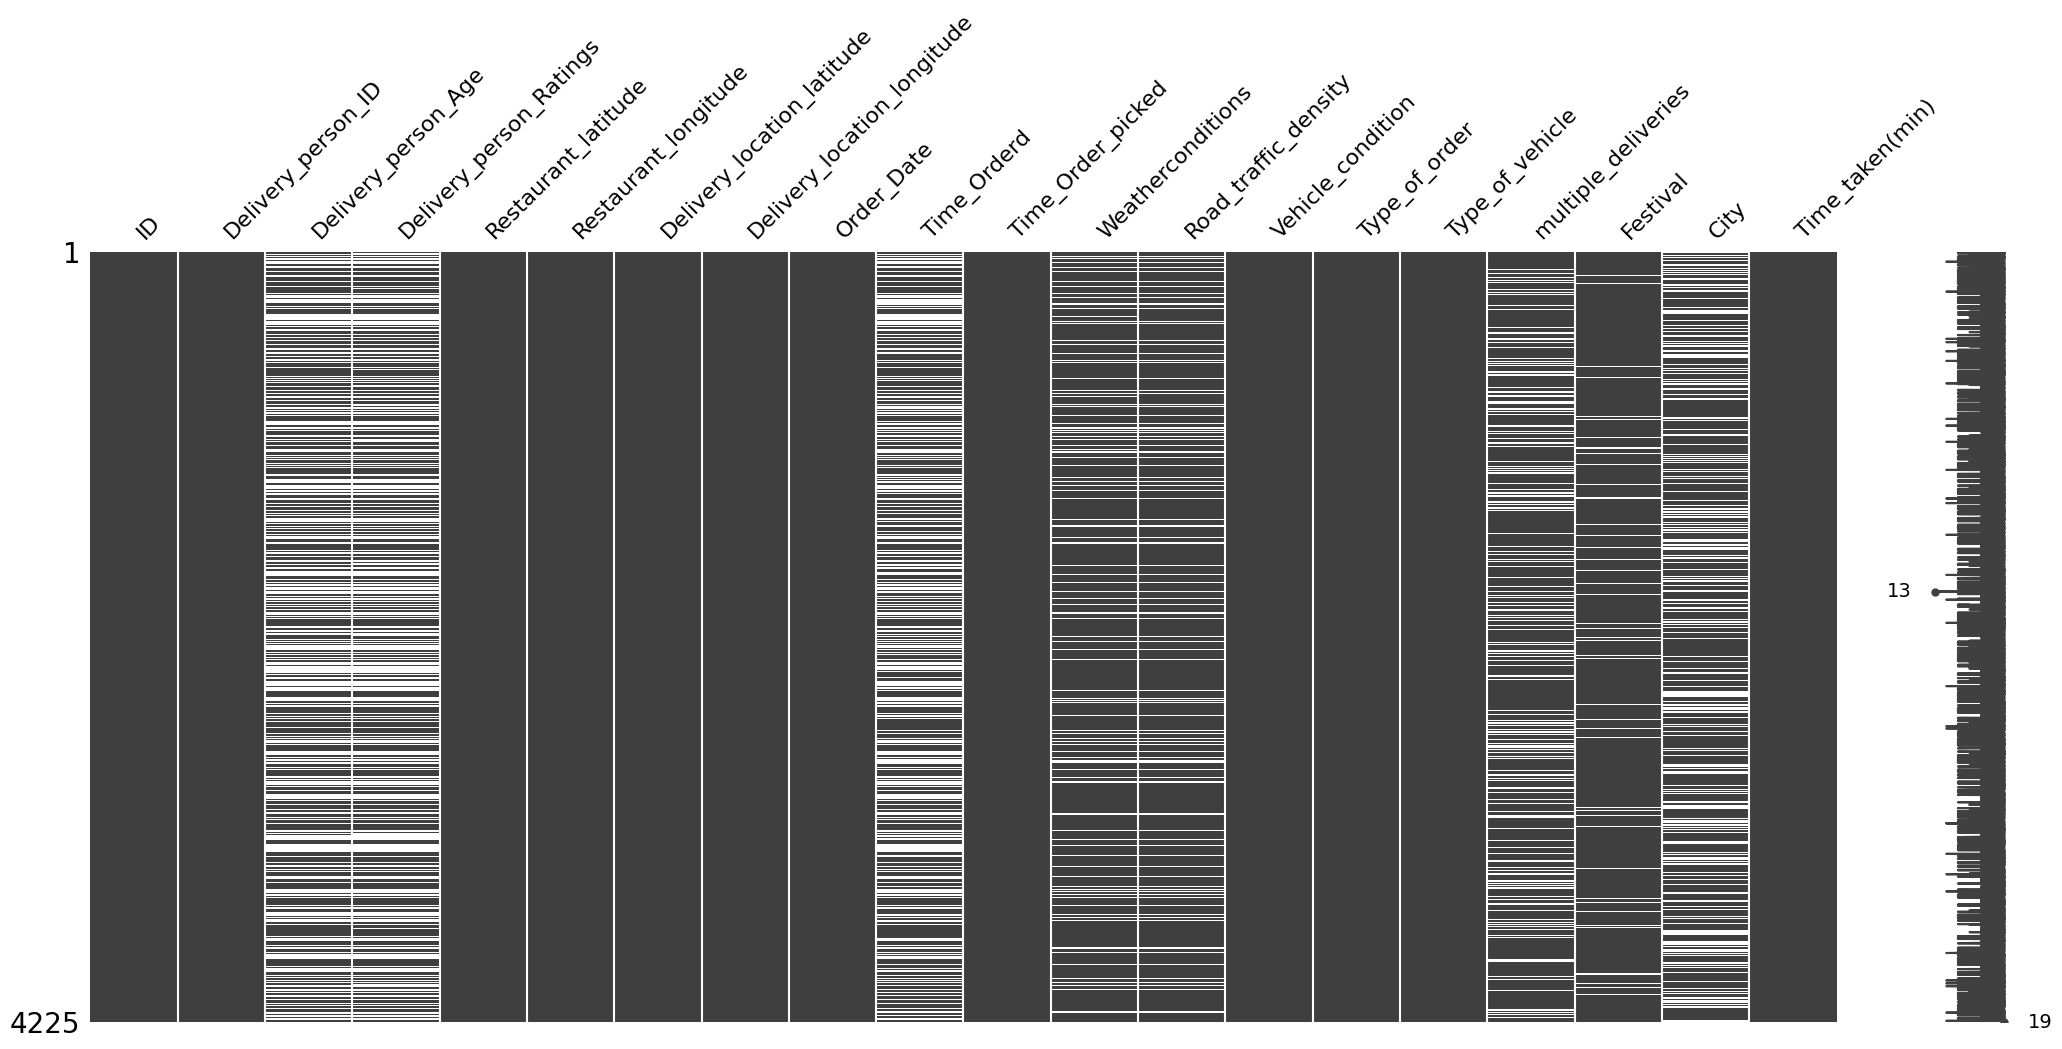

In [18]:
import missingno as msno
msno.matrix(missing_df)

<Axes: >

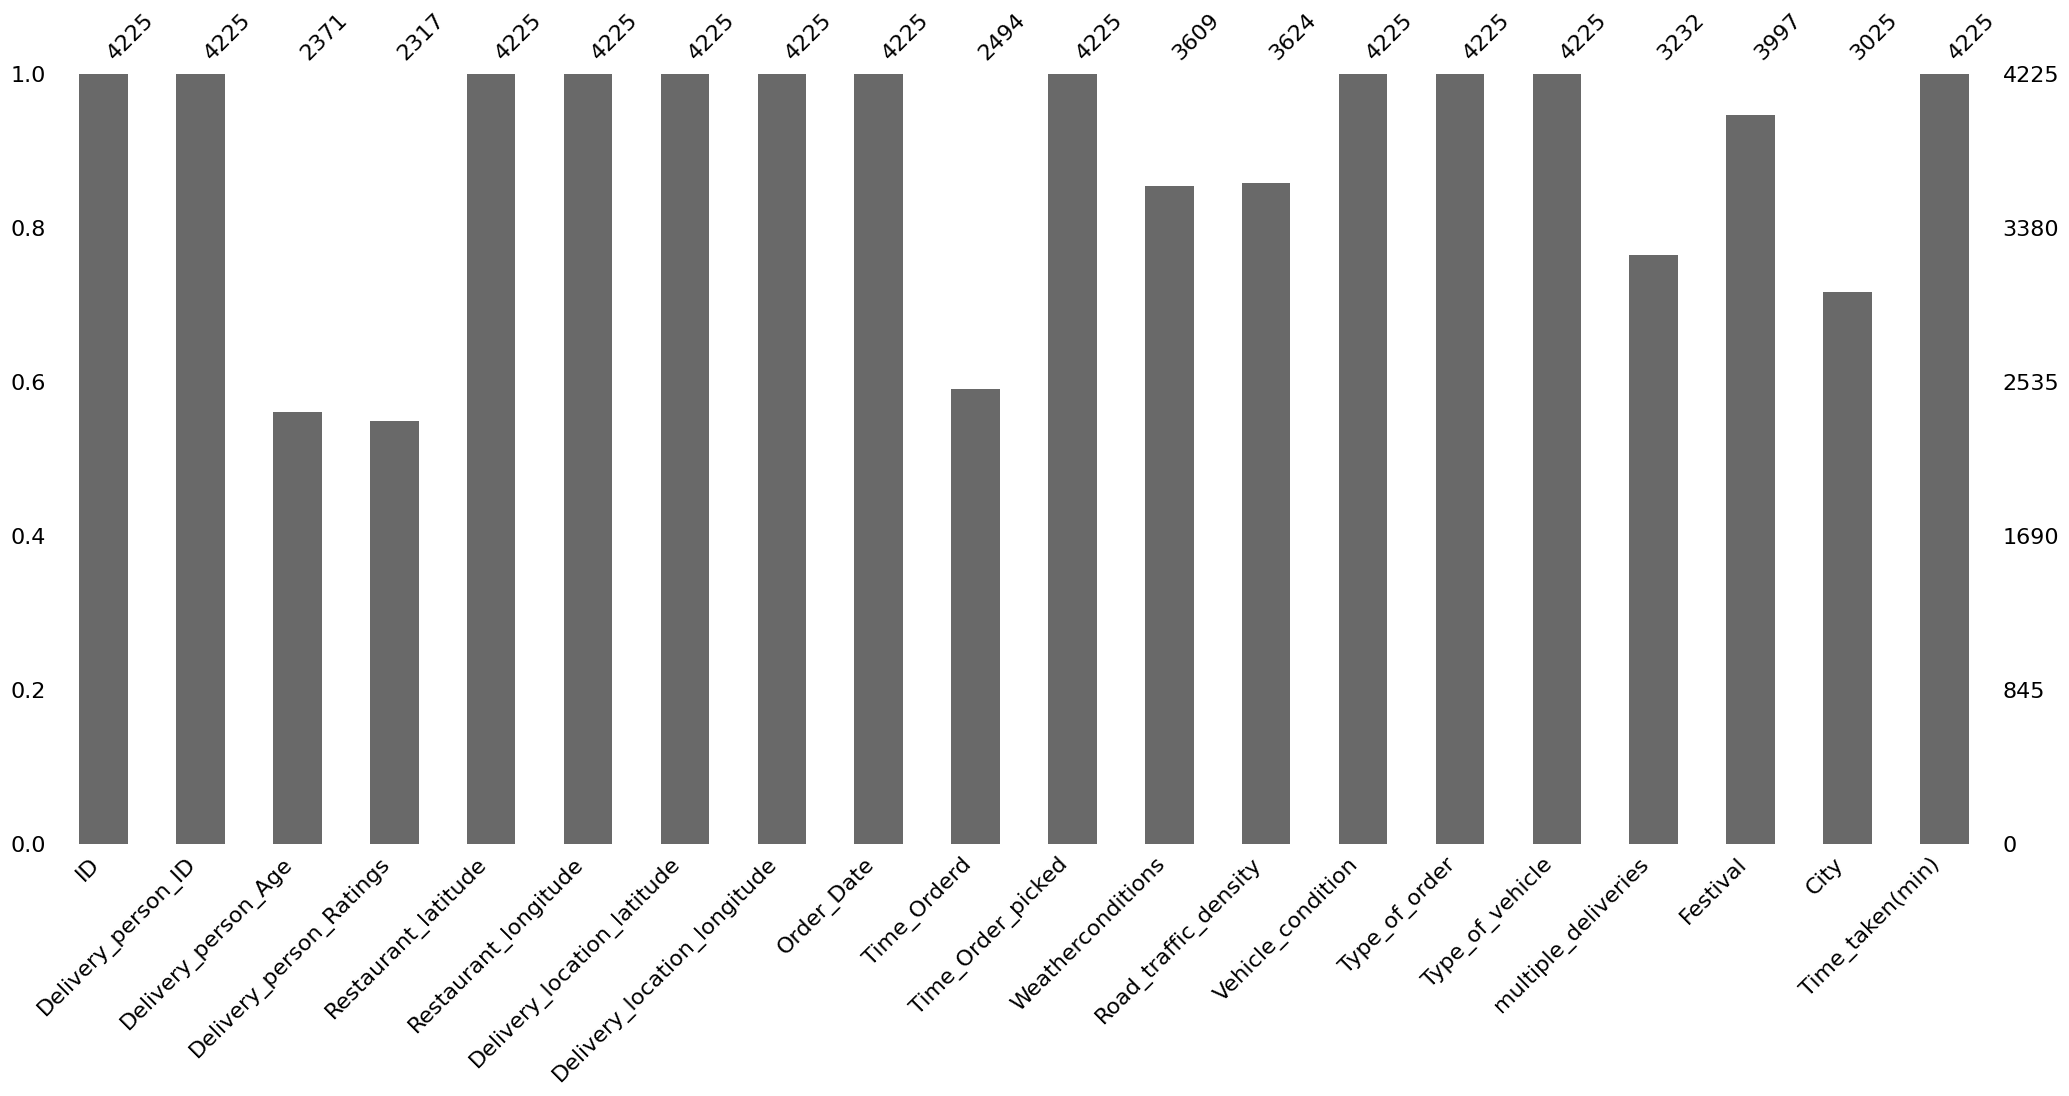

In [19]:
msno.bar(missing_df)

<Axes: >

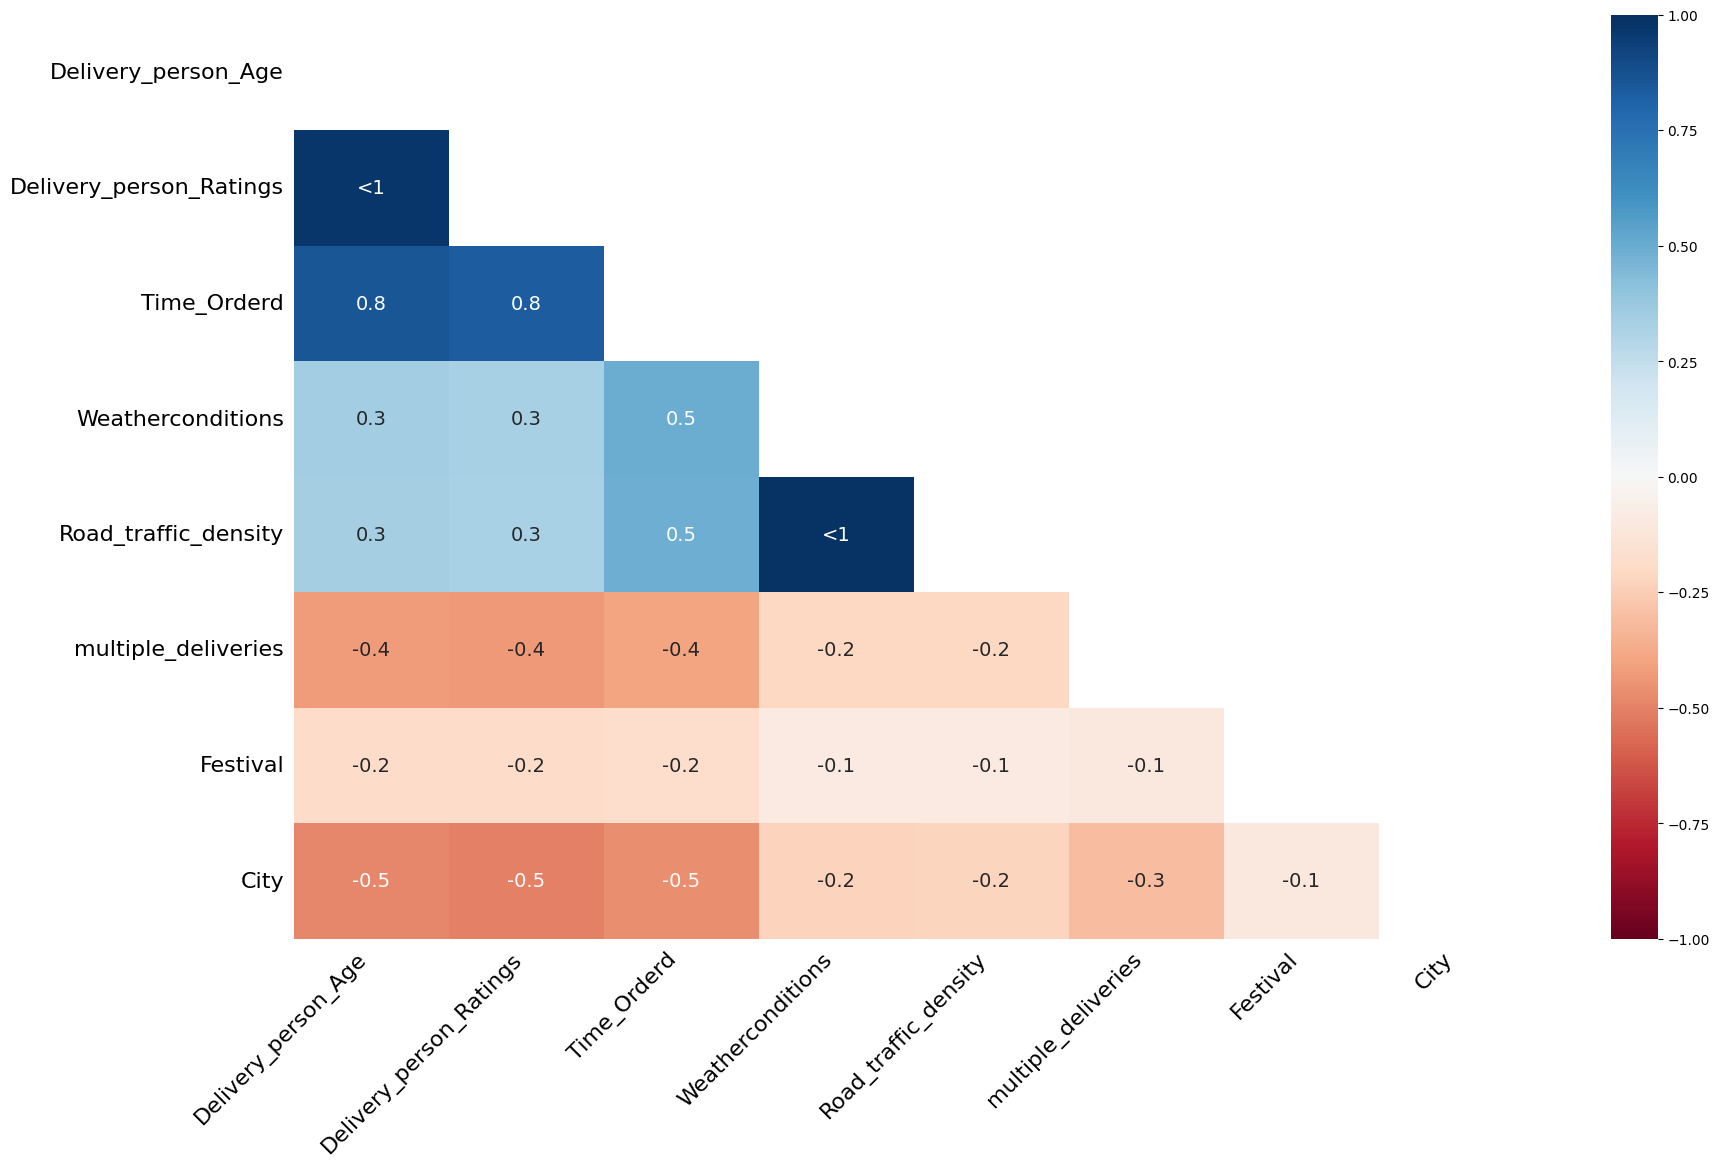

In [20]:
msno.heatmap(missing_df)

- jha jha delivery person ki age me missing values hai wha wha delivery preson kki rating bhi missing hai same order ka time bhi missing hai 
- jha jha weather conditions missing hai wha wha road trafic density bhi missing hai 

<Axes: >

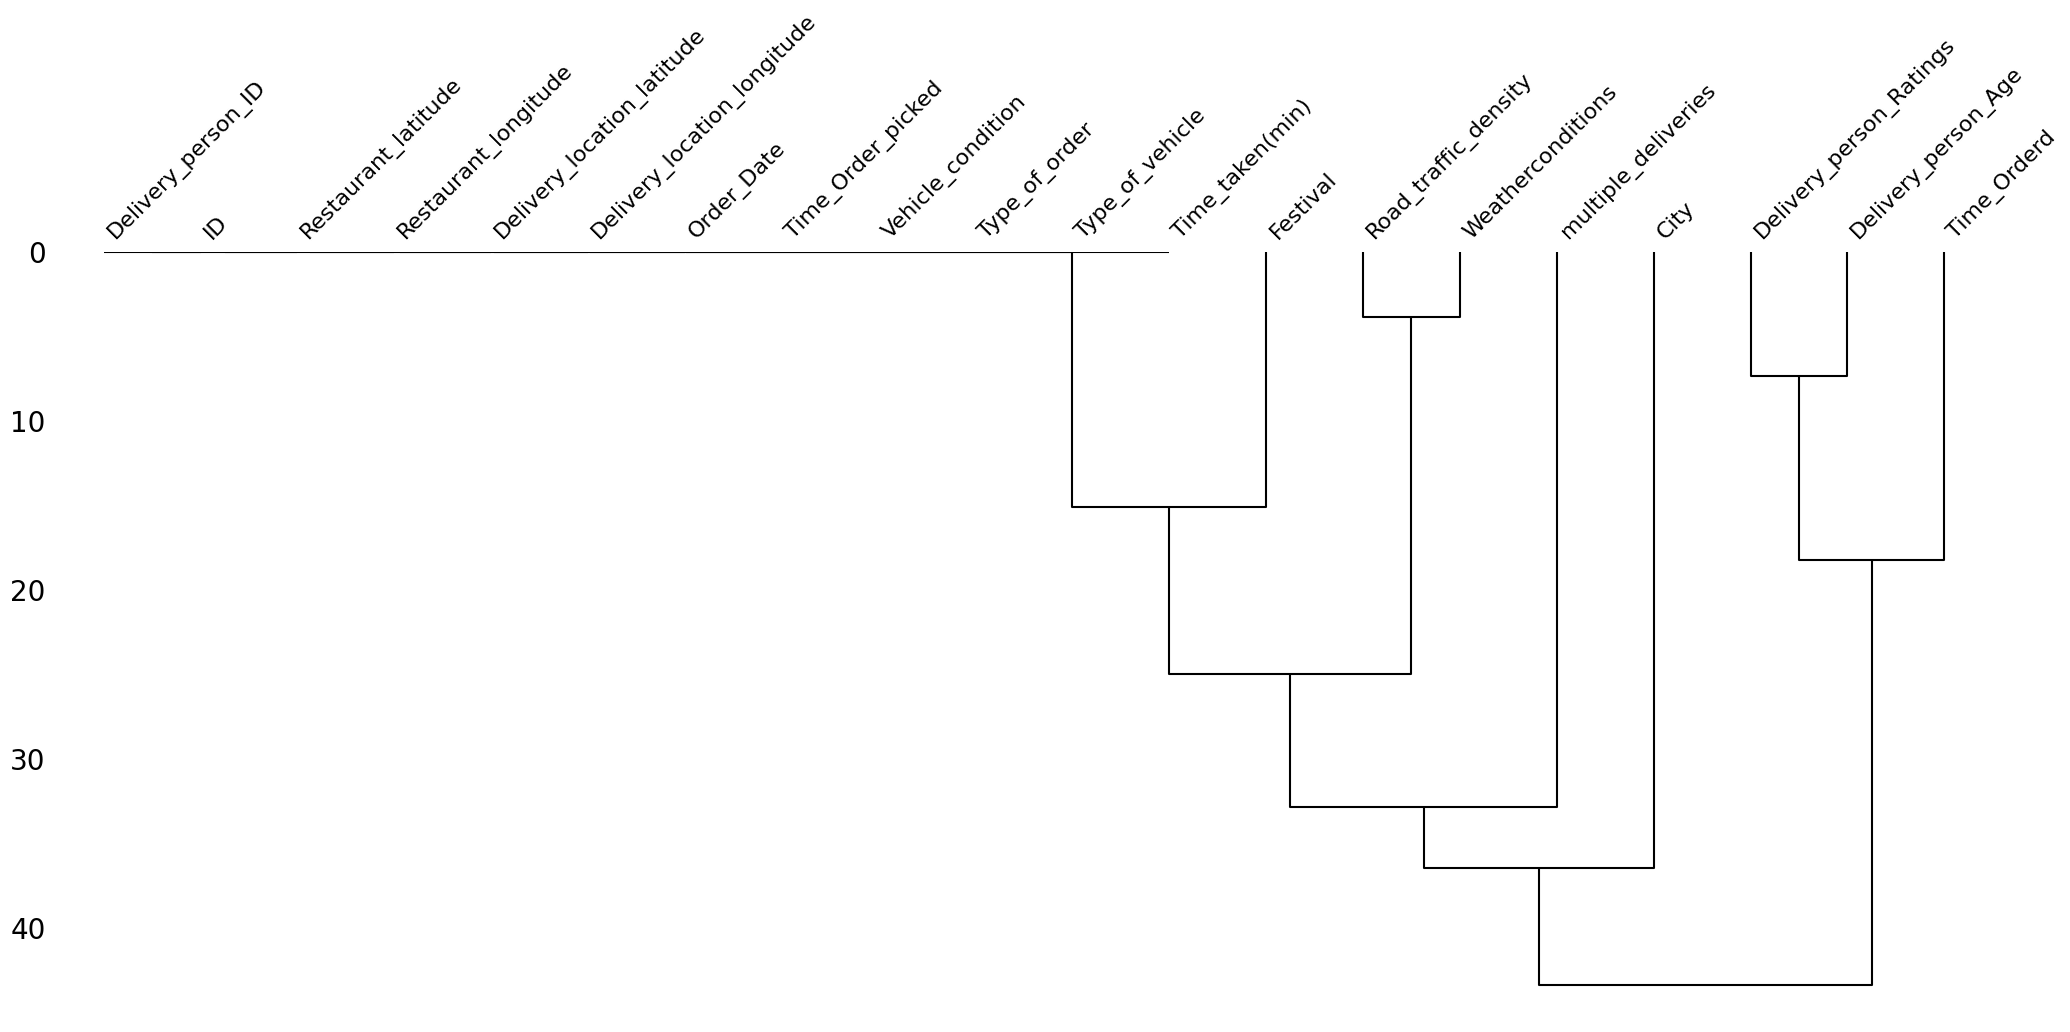

In [21]:
msno.dendrogram(missing_df)

## Data Cleaning 

In [ ]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [ ]:
def change_cols_name(data: pd.DataFrame):
    return (
        data.rename(str.lower, axis=1)
        .rename({
            'delivery_person_id': 'rider_id',
            'delivery_person_age': 'rider_age',
            'delivery_person_ratings': 'ratings',
            'delivery_location_latitude': 'delivery_latitude',
            'delivery_location_longitude': 'delivery_longitude',
            'time_orderd': 'order_time',
            'time_order_picked': 'order_picked_time',
            'weatherconditions': 'weather',
            'road_traffic_density': 'traffic',
            'city': 'city_type',
            'time_taken(min)': 'time_taken' 
        }, axis=1)
    )


df = change_cols_name(df)

- koi duplicated rows nhi hai 

In [ ]:
df.head(5)

,id,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


## **Column Wise Cleaning**

### Rider_id

In [ ]:
df['rider_id'].nunique()

1320

In [ ]:
df['rider_id'].value_counts()

,count
rider_id,
PUNERES01DEL01,67
JAPRES11DEL02,67
VADRES08DEL02,66
RANCHIRES02DEL01,66
HYDRES04DEL02,66
...,...
BHPRES15DEL03,7
GOARES01DEL03,7
KOLRES09DEL03,6


In [ ]:
(
    df['rider_id']
    .str.split('RES')
    .str[0]
    .rename('city_name')
)

,city_name
0,INDO
1,BANG
2,BANG
3,COIMB
4,CHEN
...,...
45588,JAP
45589,AGR
45590,CHEN
45591,COIMB


### Age

In [ ]:
df['rider_age'].dtype

dtype('O')

In [ ]:
df['rider_age'].astype(float).describe()

,rider_age
count,43739.000000
mean,29.567137
std,5.815155
min,15.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,50.000000


- minimum age 15 jo ki legal age nhi hai

<Axes: ylabel='rider_age'>

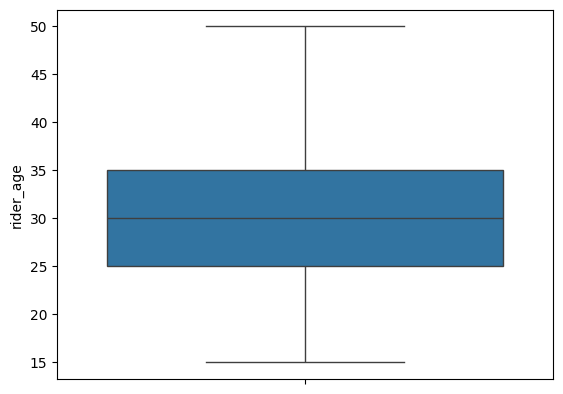

In [30]:
sns.boxplot(df['rider_age'].astype(float))

In [31]:
# minor rider 
minor_data = df[df['rider_age'].astype(float) < 18]
minor_data

,id,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
2387,0x564,JAPRES15DEL03,15,1,-26.891191,75.802083,26.981191,75.892083,12-03-2022,NaN,17:20:00,conditions NaN,NaN,3,Meal,motorcycle,0,No,Urban,(min) 15
2905,0xcd0,INDORES010DEL03,15,1,22.750040,75.902847,22.810040,75.962847,03-04-2022,NaN,20:30:00,conditions NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 29
2951,0x91a,SURRES17DEL03,15,1,21.149569,72.772697,21.209569,72.832697,21-03-2022,NaN,22:10:00,conditions NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 20
5902,0x474,CHENRES15DEL03,15,1,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,20:50:00,conditions NaN,NaN,3,Drinks,bicycle,1,No,Metropolitian,(min) 25
9156,0x73f,BANGRES05DEL01,15,1,12.970324,77.645748,13.080324,77.755748,25-03-2022,NaN,23:25:00,conditions NaN,NaN,3,Buffet,motorcycle,2,No,Metropolitian,(min) 34
10900,0x1b49,MUMRES14DEL02,15,1,19.181300,72.836191,19.231300,72.886191,30-03-2022,NaN,20:55:00,conditions NaN,NaN,3,Buffet,motorcycle,1,No,Metropolitian,(min) 39
11125,0x40b,SURRES12DEL01,15,1,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,11:30:00,conditions NaN,NaN,3,Meal,scooter,1,No,Urban,(min) 27
12093,0x523,INDORES03DEL02,15,1,22.751857,75.866699,22.801857,75.916699,24-03-2022,NaN,21:15:00,conditions NaN,NaN,3,Buffet,bicycle,0,No,Metropolitian,(min) 28
15124,0x18b0,RANCHIRES02DEL01,15,1,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,23:55:00,conditions NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 21
15927,0x550,CHENRES08DEL02,15,1,13.022394,80.242439,13.072394,80.292439,11-03-2022,NaN,18:10:00,conditions NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 17


- in sbme rartings 1 hai 
- weather, traffic, order_time ki values nan hai 
- age 15 hai jo premisible nhi hai 
- also latitude and laungitude ki values -ve and 0 ha kuch me 

**inko drop kr dena chahiye**

In [ ]:
minor_index = minor_data.index.tolist()
len(minor_index)

38

### Ratings

In [ ]:
df['ratings'].dtype

dtype('O')

In [ ]:
df['ratings'].astype(float).describe()

,ratings
count,43685.000000
mean,4.633780
std,0.334716
min,1.000000
25%,4.500000
50%,4.700000
75%,4.900000
max,6.000000


- maximum rating 6 jo ki unusual hai 

<Axes: ylabel='ratings'>

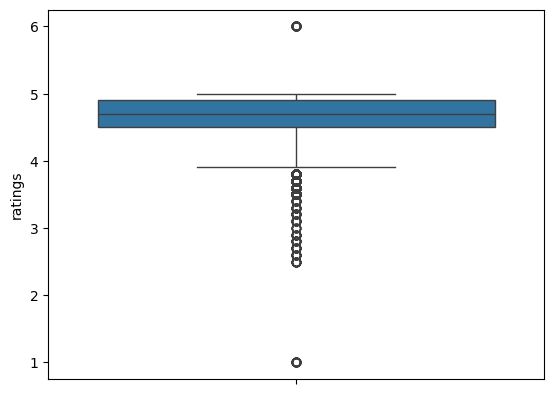

In [35]:
sns.boxplot(df['ratings'].astype(float))

- 1 star wale minors hai 

In [36]:
six_star_data = df[df['ratings'] == '6']
len(six_star_data)

53

In [37]:
six_star_data

,id,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
3586,0x46d,BANGRES05DEL01,50,6,-12.970324,-77.645748,13.010324,77.685748,13-03-2022,NaN,12:30:00,conditions NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 25
4714,0x493,HYDRES17DEL01,50,6,-17.451976,-78.385883,17.561976,78.495883,04-04-2022,NaN,23:20:00,conditions NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 27
5169,0x4f2,JAPRES08DEL01,50,6,-26.910262,-75.783013,27.020262,75.893013,18-03-2022,NaN,18:50:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 20
5362,0x430,BANGRES19DEL01,50,6,12.914264,77.678400,13.024264,77.788400,06-04-2022,NaN,20:55:00,conditions NaN,NaN,3,Meal,electric_scooter,1,No,Metropolitian,(min) 18
5651,0xbef1,AGRRES13DEL02,50,6,-27.159795,-78.042990,27.209795,78.092990,13-02-2022,NaN,18:05:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 20
6394,0x427,JAPRES06DEL02,50,6,26.911927,75.797282,27.041927,75.927282,02-04-2022,NaN,22:10:00,conditions NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 20
7031,0x3eb,MYSRES15DEL02,50,6,-12.352058,-76.606650,12.372058,76.626650,15-03-2022,NaN,10:00:00,conditions NaN,NaN,3,Buffet,scooter,1,No,Metropolitian,(min) 14
7681,0xd42,VADRES09DEL01,50,6,0.000000,0.000000,0.010000,0.010000,21-03-2022,NaN,08:35:00,conditions NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 22
9499,0x3f0,BANGRES010DEL01,50,6,12.933298,77.614293,13.003298,77.684293,12-03-2022,NaN,18:25:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Urban,(min) 17
9535,0x3ef,RANCHIRES13DEL01,50,6,-23.374989,-85.335486,23.444989,85.405486,20-03-2022,NaN,17:55:00,conditions NaN,NaN,3,Snack,bicycle,1,No,Metropolitian,(min) 32


- isme age sbki 50 hai 
- weather, traffic, order_time ka value missing hai

**inko bhi drop kr dena chahiye**

In [ ]:
six_star_index = six_star_data.index.tolist()

### Location Columns

In [39]:
location_columns = df.columns[4:8].tolist()
location_columns

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [40]:
location_subset = df.loc[:, location_columns]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...
45588,26.902328,75.794257,26.912328,75.804257
45589,0.000000,0.000000,0.070000,0.070000
45590,13.022394,80.242439,13.052394,80.272439
45591,11.001753,76.986241,11.041753,77.026241


- India ki coordinates Latitude : 8°4′ N to 37°6′ N
- Longitude 68°7′ E to 97°25′ E

In [41]:
location_subset.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702
std,8.185109,22.883647,7.335122,21.118812
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.546947,75.898497,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


In [42]:
lower_bound_lat = 8.4
lower_bound_long = 68.7

In [43]:
df.loc[
    (df['restaurant_latitude'] < lower_bound_lat) | 
    (df['restaurant_longitude'] < lower_bound_long) | 
    (df['delivery_latitude'] < lower_bound_lat) | 
    (df['delivery_longitude'] < lower_bound_long) 
]

,id,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
33,0x2876,RANCHIRES02DEL01,32,3.5,0.0,0.0,0.11,0.11,08-03-2022,21:35:00,21:45:00,conditions Stormy,Jam,1,Snack,scooter,0,No,Urban,(min) 35
52,0xc1ff,AURGRES20DEL03,25,5,0.0,0.0,0.03,0.03,13-02-2022,22:10:00,22:25:00,conditions Cloudy,Low,0,Snack,motorcycle,0,No,Metropolitian,(min) 15
57,0x8e6c,VADRES02DEL02,39,4.2,0.0,0.0,0.08,0.08,02-03-2022,20:35:00,20:50:00,conditions Fog,Jam,2,Snack,scooter,1,No,Semi-Urban,(min) 49
59,0x395b,VADRES04DEL03,36,4.7,0.0,0.0,0.06,0.06,13-03-2022,20:15:00,20:20:00,conditions Cloudy,Jam,1,Snack,motorcycle,1,No,Metropolitian,(min) 30
67,0x98aa,VADRES16DEL02,23,4.8,0.0,0.0,0.02,0.02,07-03-2022,10:40:00,10:50:00,conditions Stormy,Low,1,Meal,scooter,1,No,Metropolitian,(min) 15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45569,0x1de4,VADRES02DEL01,26,4.9,0.0,0.0,0.07,0.07,10-03-2022,19:35:00,19:45:00,conditions Fog,Jam,1,Drinks,scooter,1,No,Metropolitian,(min) 32
45576,0x2bed,RANCHIRES02DEL02,34,4.2,0.0,0.0,0.13,0.13,04-04-2022,17:25:00,17:30:00,conditions Stormy,Medium,0,Drinks,motorcycle,3,No,Urban,(min) 48
45577,0x373f,VADRES12DEL03,25,4.7,0.0,0.0,0.09,0.09,29-03-2022,22:10:00,22:15:00,conditions Cloudy,Low,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
45579,0xdf1d,BHPRES19DEL02,32,4.6,0.0,0.0,0.05,0.05,15-02-2022,18:10:00,18:20:00,conditions Stormy,Medium,2,Drinks,scooter,1,No,Metropolitian,(min) 27


In [44]:
df.loc[
    (df['restaurant_latitude'] < lower_bound_lat) | 
    (df['restaurant_longitude'] < lower_bound_long) | 
    (df['delivery_latitude'] < lower_bound_lat) | 
    (df['delivery_longitude'] < lower_bound_long) 
].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition
count,4071.000000,4071.000000,4071.000000,4071.000000,4071.000000
mean,-2.149416,2.068601,2.212538,8.299885,1.095554
std,6.537913,25.270676,6.538283,23.980011,0.897147
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,0.000000,0.000000,0.040000,0.040000,0.000000
50%,0.000000,0.000000,0.070000,0.070000,1.000000
75%,0.000000,0.000000,0.110000,0.110000,2.000000
max,0.000000,88.433452,31.045562,88.523452,3.000000


(array([1, 2, 3, 4, 5]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude'),
  Text(5, 0, 'vehicle_condition')])

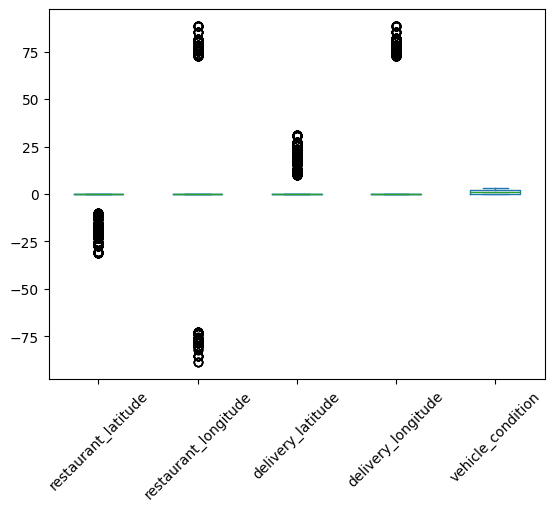

In [45]:
df.loc[
    (df['restaurant_latitude'] < lower_bound_lat) | 
    (df['restaurant_longitude'] < lower_bound_long) | 
    (df['delivery_latitude'] < lower_bound_lat) | 
    (df['delivery_longitude'] < lower_bound_long) 
].plot(kind='box')
plt.xticks(rotation=45)

- -ve values ko correct kr skte hai abs values leke 


(array([1, 2, 3, 4]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude')])

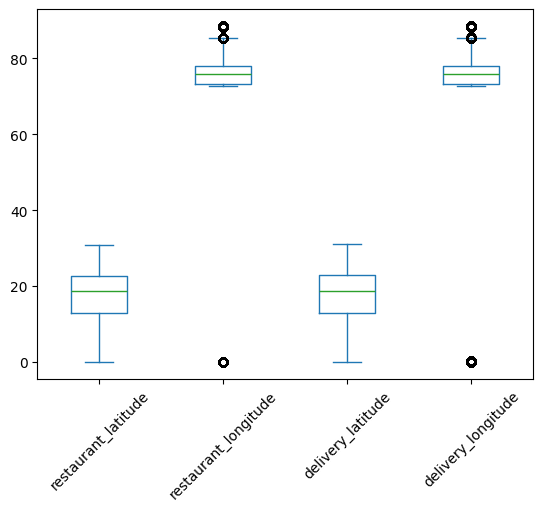

In [46]:
(
    location_subset.abs()
    .plot(kind='box')
)
plt.xticks(rotation=45)

In [47]:
# bache hue rows 
(
    location_subset.abs()
    .loc[lambda df_:
        (df_['restaurant_latitude'] < lower_bound_lat) |
        (df_['restaurant_longitude'] < lower_bound_long) | 
        (df_['delivery_latitude'] < lower_bound_lat) |
        (df_['delivery_longitude'] < lower_bound_long) 
    ].shape[0]
)

3640

In [48]:
location_subset.abs().loc[lambda df_:
        (df_['restaurant_latitude'] < lower_bound_lat) |
        (df_['restaurant_longitude'] < lower_bound_long) | 
        (df_['delivery_latitude'] < lower_bound_lat) |
        (df_['delivery_longitude'] < lower_bound_long) 
    ]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
33,0.0,0.0,0.11,0.11
52,0.0,0.0,0.03,0.03
57,0.0,0.0,0.08,0.08
59,0.0,0.0,0.06,0.06
67,0.0,0.0,0.02,0.02
...,...,...,...,...
45569,0.0,0.0,0.07,0.07
45576,0.0,0.0,0.13,0.13
45577,0.0,0.0,0.09,0.09
45579,0.0,0.0,0.05,0.05


- all are less than 1

### order_data

In [49]:
df['order_date'].isna().sum()

np.int64(0)

In [50]:
df['order_date'].unique()

array(['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022',
       '11-03-2022', '04-03-2022', '14-03-2022', '20-03-2022',
       '12-02-2022', '13-02-2022', '14-02-2022', '02-04-2022',
       '01-03-2022', '16-03-2022', '15-02-2022', '10-03-2022',
       '27-03-2022', '12-03-2022', '01-04-2022', '05-03-2022',
       '11-02-2022', '08-03-2022', '03-04-2022', '30-03-2022',
       '28-03-2022', '18-03-2022', '06-04-2022', '04-04-2022',
       '24-03-2022', '09-03-2022', '02-03-2022', '13-03-2022',
       '29-03-2022', '31-03-2022', '17-03-2022', '07-03-2022',
       '15-03-2022', '16-02-2022', '03-03-2022', '18-02-2022',
       '23-03-2022', '17-02-2022', '06-03-2022', '21-03-2022'],
      dtype=object)

In [51]:
order_date = pd.to_datetime(df['order_date'], dayfirst=True)

order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

In [52]:
order_date.agg(['min', 'min']).set_axis(['start', 'end'], axis=0)

,order_date
start,2022-02-11
end,2022-02-11


In [53]:
def extract_datetime_features(ser):
    date_col = pd.to_datetime(ser, dayfirst=True)

    return(
        pd.DataFrame({
            'day': date_col.dt.day,
            'month': date_col.dt.month,
            'year': date_col.dt.year,
            'day_of_week': date_col.dt.day_name(),
            'is_weekend': date_col.dt.day_name().isin(['Saturday', 'Sunday']).astype(int)
        })
    )

In [54]:
extract_datetime_features(df['order_date'])

,day,month,year,day_of_week,is_weekend
0,19,3,2022,Saturday,1
1,25,3,2022,Friday,0
2,19,3,2022,Saturday,1
3,5,4,2022,Tuesday,0
4,26,3,2022,Saturday,1
...,...,...,...,...,...
45588,24,3,2022,Thursday,0
45589,16,2,2022,Wednesday,0
45590,11,3,2022,Friday,0
45591,7,3,2022,Monday,0


### order time and picked time

In [55]:
order_time_hour = pd.to_datetime(df.replace('NaN ', np.nan)['order_time'], format='mixed').dt.hour 
order_time_hour

,order_time
0,11.0
1,19.0
2,8.0
3,18.0
4,13.0
...,...
45588,11.0
45589,19.0
45590,23.0
45591,13.0


In [56]:
def time_of_day(ser):
    time_col = pd.to_datetime(ser, format='mixed').dt.hour

    return (
        np.select(condlist=[
            (time_col.between(6, 12, inclusive='left')),
            (time_col.between(12, 17, inclusive='left')),
            (time_col.between(17, 20, inclusive='left')),
            (time_col.between(20, 24, inclusive='left')),
        ],
        choicelist = ['morning', 'afternoon', 'evening', 'night'],
        default='after_midnight')
    )

In [57]:
time_subset = df.loc[:, ['order_time', 'order_picked_time']]
time_subset

,order_time,order_picked_time
0,11:30:00,11:45:00
1,19:45:00,19:50:00
2,08:30:00,08:45:00
3,18:00:00,18:10:00
4,13:30:00,13:45:00
...,...,...
45588,11:35:00,11:45:00
45589,19:55:00,20:10:00
45590,23:50:00,00:05:00
45591,13:35:00,13:40:00


In [58]:
(
    time_subset
    .dtypes
)

,0
order_time,object
order_picked_time,object


In [59]:
time_subset.columns.tolist()

['order_time', 'order_picked_time']

In [60]:
# calculate the pickup time
(
    time_subset
    .assign(**{
        col: pd.to_datetime(time_subset[col].replace('NaN ', np.nan), format='mixed')
        for col in time_subset.columns.tolist()
    })
    .assign(
        pickup_time = lambda x: (x['order_picked_time'] - x['order_time']).dt.seconds / 60,
        order_time_hour = lambda x: x['order_time'].dt.hour,
        order_time_of_day = lambda x: x['order_time_hour'].pipe(time_of_day)
    )
    .drop(columns=['order_time', 'order_picked_time'])
)

,pickup_time,order_time_hour,order_time_of_day
0,15.0,11.0,after_midnight
1,5.0,19.0,after_midnight
2,15.0,8.0,after_midnight
3,10.0,18.0,after_midnight
4,15.0,13.0,after_midnight
...,...,...,...
45588,10.0,11.0,after_midnight
45589,15.0,19.0,after_midnight
45590,15.0,23.0,after_midnight
45591,5.0,13.0,after_midnight


### weather

In [61]:
df['weather'].value_counts()

,count
weather,
conditions Fog,7654
conditions Stormy,7586
conditions Cloudy,7536
conditions Sandstorms,7495
conditions Windy,7422
conditions Sunny,7284
conditions NaN,616


### traffic

In [62]:
df['traffic'].value_counts()

,count
traffic,
Low,15477
Jam,14143
Medium,10947
High,4425
NaN,601


In [63]:
(
    df['traffic']
    .replace('NaN ', np.nan)
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['high', 'jam', 'low', 'medium', nan], dtype=object)

### vehical condition

In [64]:
np.sort(df['vehicle_condition'].unique())

array([0, 1, 2, 3])

### type of order

In [65]:
df['type_of_order'].value_counts()

,count
type_of_order,
Snack,11533
Meal,11458
Drinks,11322
Buffet,11280


In [66]:
df['type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

In [67]:
(
    df['type_of_order']
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['snack', 'drinks', 'buffet', 'meal'], dtype=object)

### type of vehicle

In [68]:
df['type_of_vehicle'].value_counts()

,count
type_of_vehicle,
motorcycle,26435
scooter,15276
electric_scooter,3814
bicycle,68


In [69]:
df['type_of_vehicle'].unique()

array(['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle '],
      dtype=object)

In [70]:
(
    df['type_of_vehicle']
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'],
      dtype=object)

### multiple deliveries

In [71]:
df['multiple_deliveries'].value_counts()

,count
multiple_deliveries,
1,28159
0,14095
2,1985
NaN,993
3,361


In [72]:
df['multiple_deliveries'].unique()

array(['0', '1', '3', 'NaN ', '2'], dtype=object)

In [73]:
(
    df['multiple_deliveries']
    .replace('NaN ', np.nan)
    .astype(float)
    .unique()
)

array([ 0.,  1.,  3., nan,  2.])

### festival

In [74]:
df['festival'].value_counts()

,count
festival,
No,44469
Yes,896
NaN,228


In [75]:
df['festival'].unique()

array(['No ', 'Yes ', 'NaN '], dtype=object)

In [76]:
(
    df['festival']
    .replace('NaN ', np.nan)
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['no', 'yes', nan], dtype=object)

### city_type

In [77]:
df['city_type'].value_counts()

,count
city_type,
Metropolitian,34093
Urban,10136
NaN,1200
Semi-Urban,164


In [78]:
df['city_type'].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', 'NaN '], dtype=object)

In [79]:
(
    df['city_type']
    .replace('NaN ', np.nan)
    .str.lower()
    .str.rstrip()
    .unique()
)

array(['urban', 'metropolitian', 'semi-urban', nan], dtype=object)

### time taken

In [80]:
df['time_taken'].dtype

dtype('O')

In [81]:
(
    df['time_taken']
    .str.replace('(min) ', '')
    .astype(int)
)

,time_taken
0,24
1,33
2,26
3,21
4,30
...,...
45588,32
45589,36
45590,16
45591,26


## **Data Cleaning function** 

In [82]:
def data_cleaning(data: pd.DataFrame):
    return (
        data
        .drop(columns=['id'])
        .drop(index=minor_index)
        .drop(index=six_star_index)
        .replace('NaN ', np.nan)
        .assign(
            city_name = lambda x: x['rider_id'].str.split('RES').str.get(0),
            rider_age = lambda x: x['rider_age'].astype(float),
            ratings = lambda x: x['ratings'].astype(float),

            restaurant_latitude = lambda x: x['restaurant_latitude'].abs(),
            restaurant_longitude = lambda x: x['restaurant_longitude'].abs(),
            delivery_latitude = lambda x: x['delivery_latitude'].abs(),
            delivery_longitude = lambda x: x['delivery_longitude'].abs(),

            order_date = lambda x: pd.to_datetime(x['order_date'], dayfirst=True),
            order_day = lambda x: x['order_date'].dt.day,
            order_month = lambda x: x['order_date'].dt.month,
            order_day_of_week = lambda x: x['order_date'].dt.day_name().str.lower(),
            is_weekend = lambda x: (x['order_date'].dt.day_name()
                                    .isin(['Satuday', 'Sunday'])
                                    .astype(int)),

            order_time = lambda x: pd.to_datetime(x['order_time'], format='mixed'),
            order_picked_time = lambda x: pd.to_datetime(x['order_picked_time'], format='mixed'),
            pickup_time_minutes = lambda x: ((x['order_picked_time'] - x['order_time'])
                                            .dt.seconds / 60),

            order_time_hour = lambda x: x['order_time'].dt.hour,
            order_time_of_day = lambda x: x['order_time'].pipe(time_of_day),

            weather = lambda x: (
                x['weather']
                .str.replace('conditions ', '')
                .str.lower()
                .replace('nan', np.nan)
            ),

            traffic = lambda x: x['traffic'].str.rstrip().str.lower(),
            type_of_order = lambda x: x['type_of_order'].str.rstrip().str.lower(),
            type_of_vehicle = lambda x: x['type_of_vehicle'].str.rstrip().str.lower(),
            festival = lambda x: x['festival'].str.rstrip().str.lower(),
            city_type = lambda x: x['city_type'].str.rstrip().str.lower(),

            multiple_deliveries = lambda x: x['multiple_deliveries'].astype(float),
            time_taken = lambda x: (x['time_taken']
                                    .str.replace('(min) ', '')
                                    .astype(int))
        )    
        .drop(columns=['order_time', 'order_picked_time'])                
    )

In [83]:
df

,id,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [84]:
data_cleaning(df)

,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,0,15.0,11.0,morning
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,0,15.0,8.0,morning
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,0,15.0,13.0,afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,24,3,thursday,0,10.0,11.0,morning
45589,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,AGR,16,2,wednesday,0,15.0,19.0,evening
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,11,3,friday,0,15.0,23.0,night
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,7,3,monday,0,5.0,13.0,afternoon


## **Clean lat-long**

In [85]:
def clean_lat_long(data: pd.DataFrame, threshold=1):
    location_columns = location_subset.columns.tolist()

    return (
        data
        .assign(**{
            col: (
                np.where(data[col]<threshold, np.nan, data[col].values)
            )
            for col in location_columns
        })
    )

In [86]:
clean_lat_long(df).isna().sum()

,0
id,0
rider_id,0
rider_age,0
ratings,0
restaurant_latitude,4071
restaurant_longitude,3802
delivery_latitude,3640
delivery_longitude,3640
order_date,0
order_time,0


## **Advanced Data Cleaning**

In [87]:
def calculate_haversine_distance(df):
    location_columns = location_subset.columns.tolist()

    lat1 = df[location_columns[0]]
    lon1 = df[location_columns[1]]
    lat2 = df[location_columns[2]]
    lon2 = df[location_columns[3]]

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

    c = 2*np.arcsin(np.sqrt(a))
    distance = 6371*c

    return (
        df.assign(distance=distance)
    )

In [88]:

cleaned_data = (
    df.pipe(data_cleaning)
    .pipe(clean_lat_long)
    .pipe(calculate_haversine_distance)
)

In [89]:
cleaned_data

,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,19,3,saturday,0,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,19,3,saturday,0,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,26,3,saturday,0,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45589,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393


### Validate data cleaning 

In [90]:
cleaned_data['rider_age'].agg(['min', 'max'])

,rider_age
min,20.0
max,39.0


In [91]:
cleaned_data['ratings'].agg(['min', 'max'])

,ratings
min,2.5
max,5.0


(array([1, 2, 3, 4]),
 [Text(1, 0, 'restaurant_latitude'),
  Text(2, 0, 'restaurant_longitude'),
  Text(3, 0, 'delivery_latitude'),
  Text(4, 0, 'delivery_longitude')])

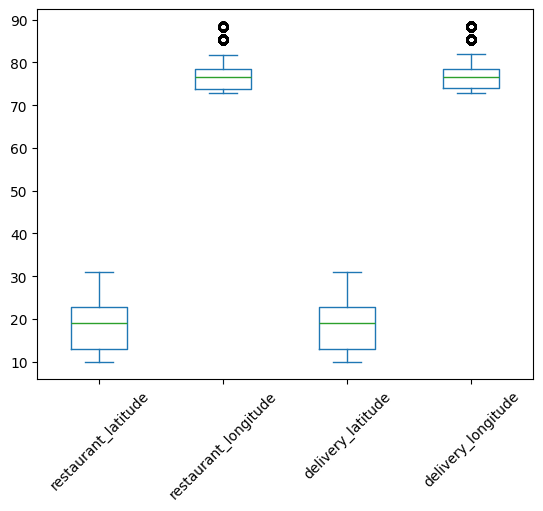

In [92]:
cleaned_data[location_columns].plot(kind='box')
plt.xticks(rotation=45)

In [93]:
cleaned_data[location_columns].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,41872.000000,41872.000000,41872.000000,41872.000000
mean,18.913696,76.921664,18.977356,76.985325
std,5.467265,3.503107,5.469056,3.503260
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.065996,73.940327
50%,19.065838,76.618203,19.124049,76.662620
75%,22.751234,78.368855,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


In [94]:
cat_cols = cleaned_data.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f'For {col} unique values are {cleaned_data[col].unique()}', end='\n\n')

For rider_id unique values are ['INDORES13DEL02 ' 'BANGRES18DEL02 ' 'BANGRES19DEL01 ' ...
 'KOCRES04DEL01 ' 'BHPRES06DEL03 ' 'GOARES03DEL03 ']

For weather unique values are ['sunny' 'stormy' 'sandstorms' 'cloudy' 'fog' 'windy' nan]

For traffic unique values are ['high' 'jam' 'low' 'medium' nan]

For type_of_order unique values are ['snack' 'drinks' 'buffet' 'meal']

For type_of_vehicle unique values are ['motorcycle' 'scooter' 'electric_scooter' 'bicycle']

For festival unique values are ['no' 'yes' nan]

For city_type unique values are ['urban' 'metropolitian' 'semi-urban' nan]

For city_name unique values are ['INDO' 'BANG' 'COIMB' 'CHEN' 'HYD' 'RANCHI' 'MYS' 'DEH' 'KOC' 'PUNE'
 'LUDH' 'KNP' 'MUM' 'KOL' 'JAP' 'SUR' 'GOA' 'AURG' 'AGR' 'VAD' 'ALH' 'BHP']

For order_day_of_week unique values are ['saturday' 'friday' 'tuesday' 'monday' 'sunday' 'wednesday' 'thursday']

For order_time_of_day unique values are ['morning' 'evening' 'afternoon' 'night' 'after_midnight']



<Axes: >

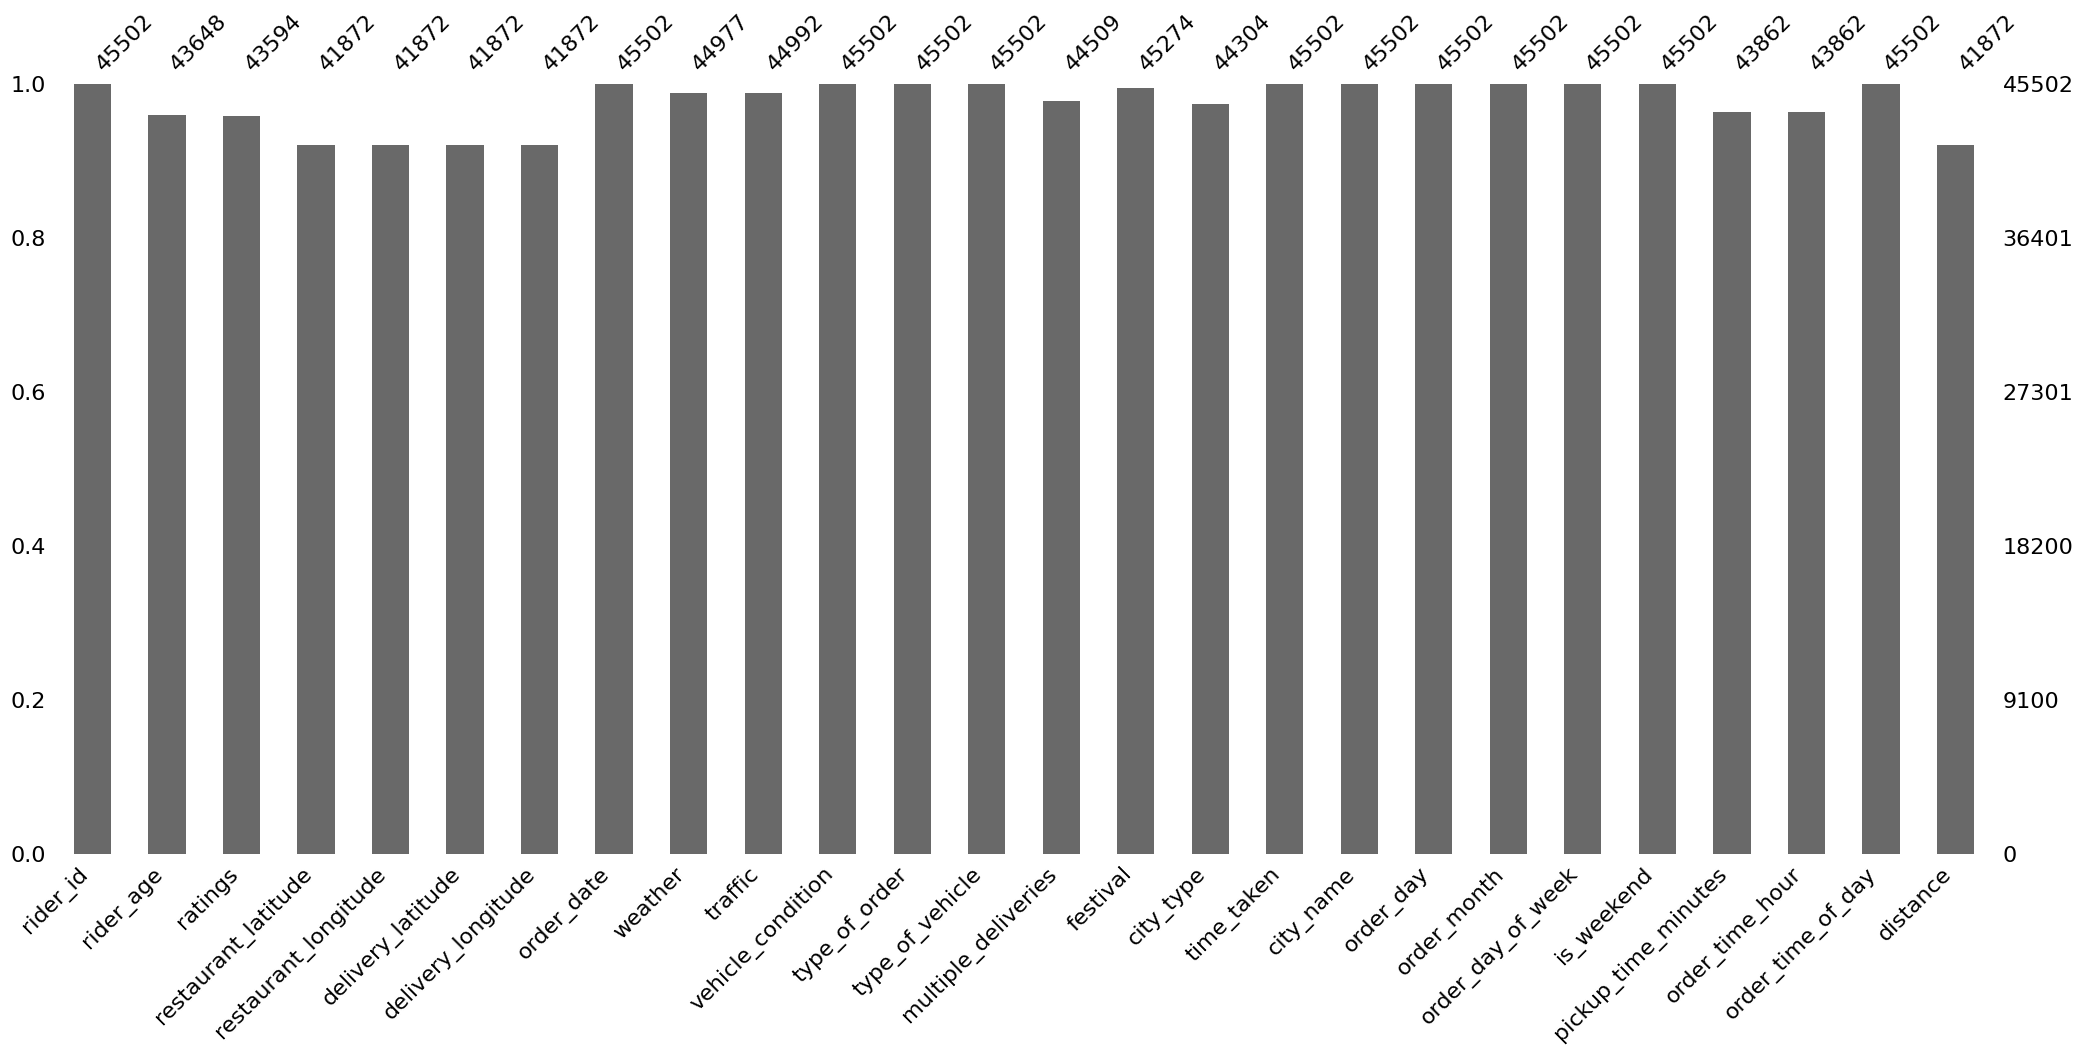

In [95]:
msno.bar(cleaned_data)

<Axes: >

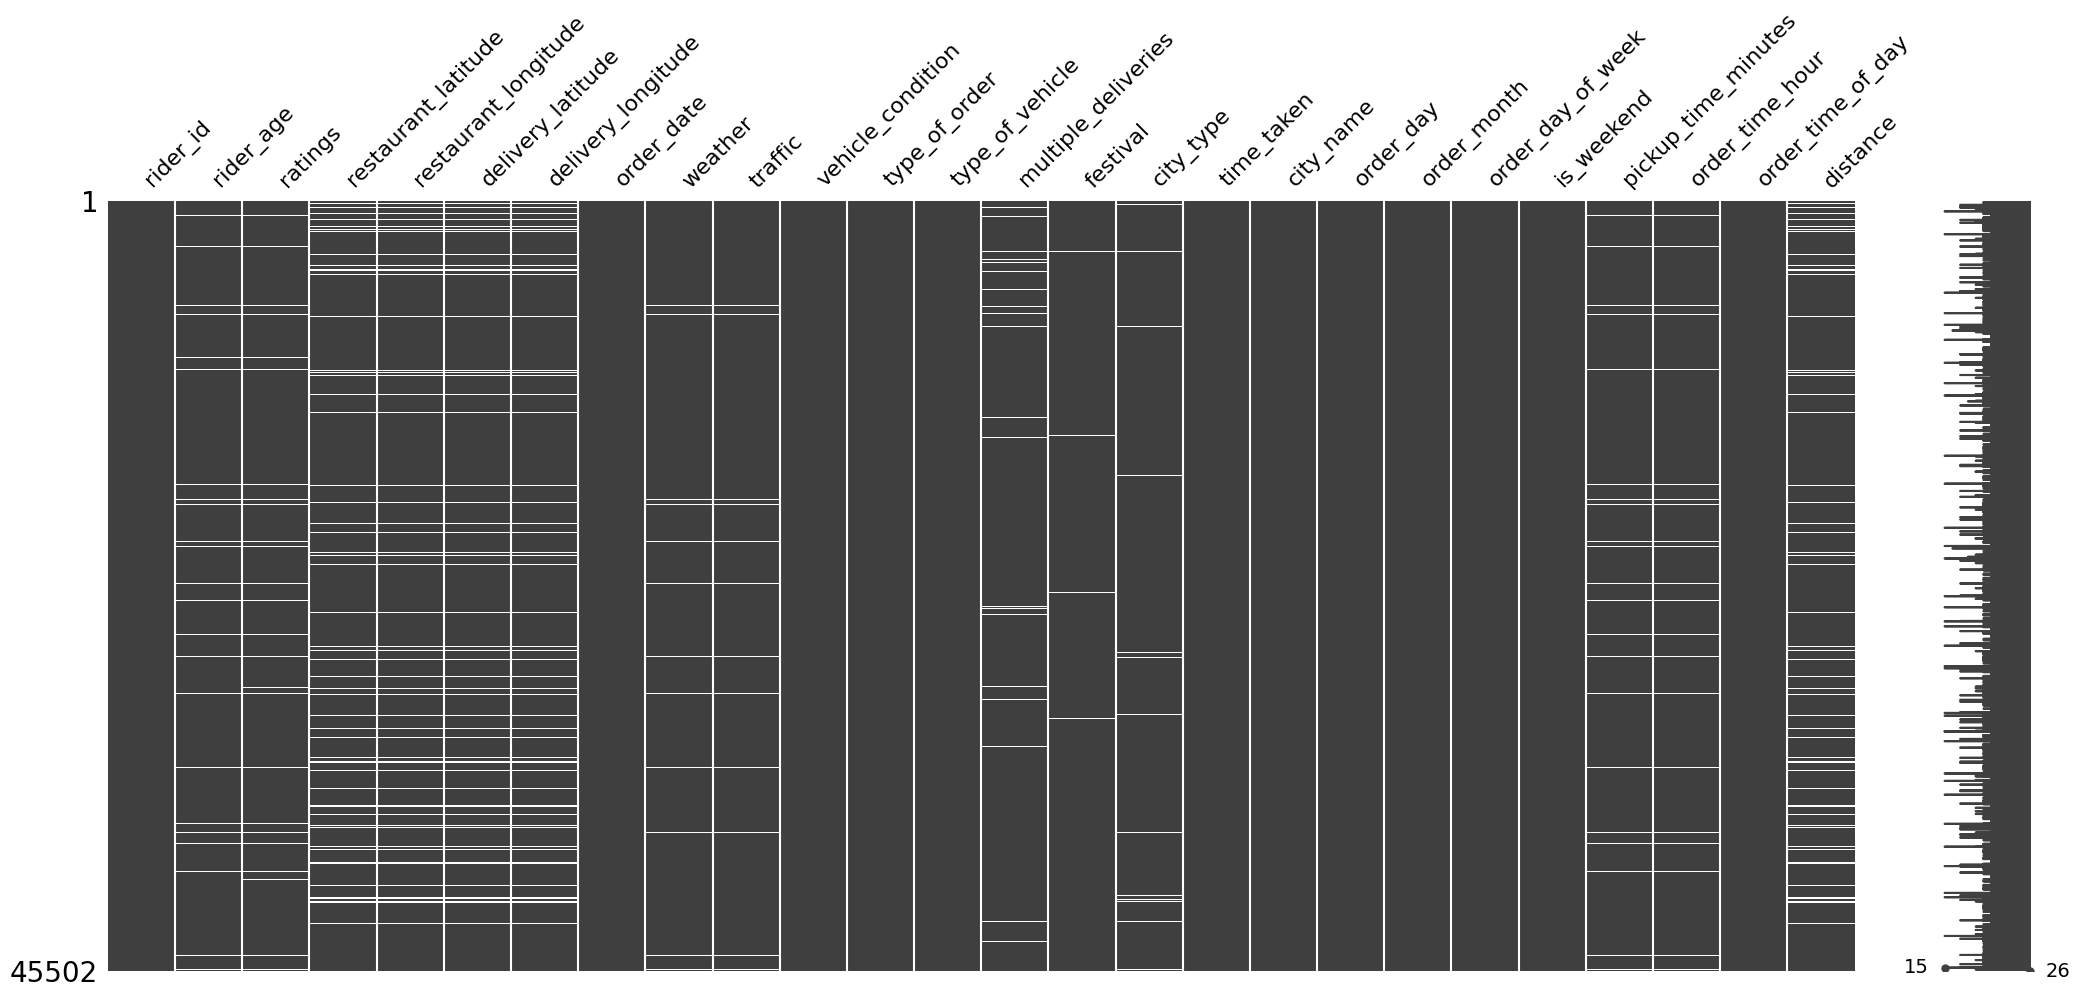

In [96]:
msno.matrix(cleaned_data)

<Axes: >

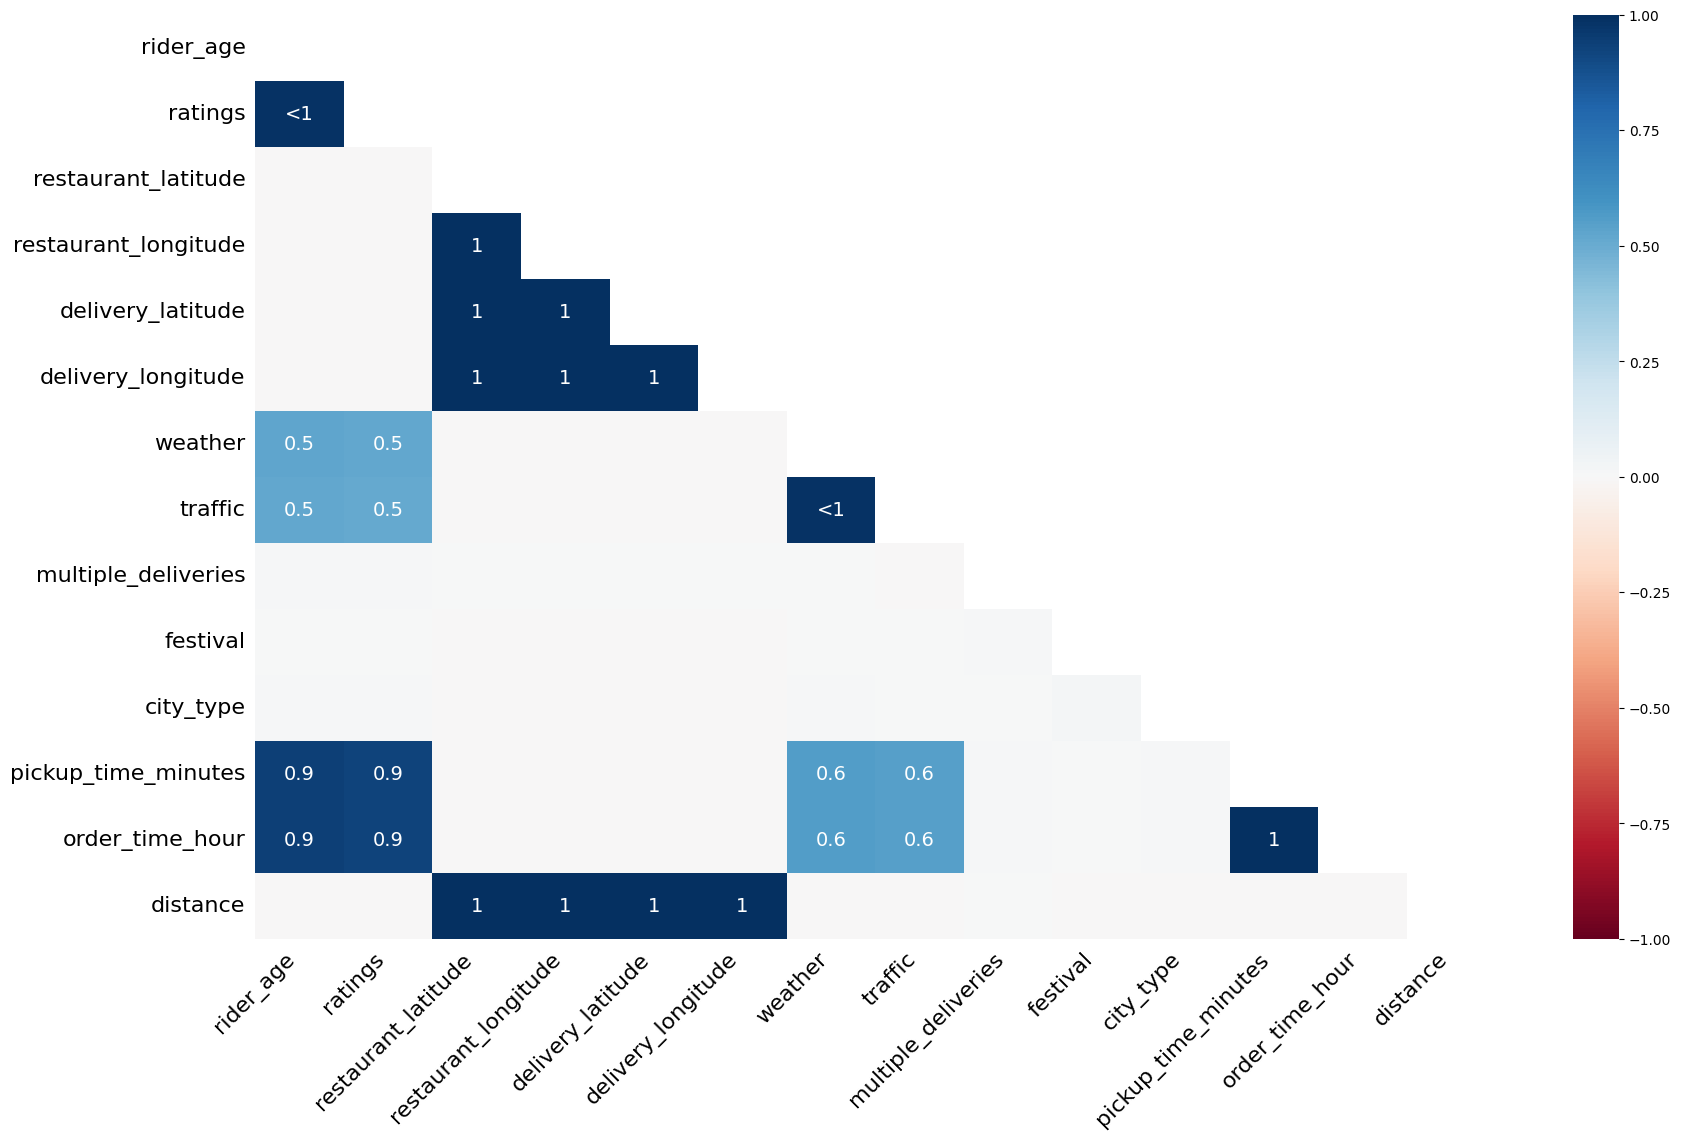

In [97]:
msno.heatmap(cleaned_data)

## Save cleaned data

In [98]:
cleaned_data.to_csv('cleaned_data.csv', index=False)

In [99]:
cleaned_data_load = pd.read_csv('cleaned_data.csv')

In [100]:
cleaned_data_load.dtypes

,0
rider_id,object
rider_age,float64
ratings,float64
restaurant_latitude,float64
restaurant_longitude,float64
delivery_latitude,float64
delivery_longitude,float64
order_date,object
weather,object
traffic,object
